# **Milestone 4** **Robust Anomaly Detection in US Childcare Costs Using Income Adjusted Residuals**

**Q2: Which counties have childcare costs that are unusually high relative to peers with similar income levels, and are these anomalies persistent from 2008–2018 or concentrated in specific years?**

**1.Refined Problem Statement & Focus**

In Milestone 4, my personal research focus stays on the same core question from Q2. I study which counties have childcare costs that are unusually high compared to other counties with similar income levels, and whether these counties remain unusually high over time. The topic has not changed, but the focus is more refined.

In M2 and M3, I mainly reported a list of anomaly counties and a basic persistence pattern. In M4, my goal is to test how stable these results are under reasonable alternative choices. I move from simply finding anomalies to checking whether the anomaly and persistence conclusions still hold when I change key modeling and preprocessing settings. This refinement is important because the dataset has missing years and the anomaly definition depends on design choices, so I need to show which findings are reliable and which are sensitive.

To do this, I challenge three assumptions. First, I test whether pooled residuals are enough by comparing them with year specific residuals. Second, I test whether the top 5 percent anomaly rule is stable by comparing it with other cutoffs such as top 2.5 percent and top 10 percent. Third, I test whether missing value handling changes the persistence and trajectory conclusions by comparing different filling strategies and scaling choices. The main goal of M4 is to improve credibility and interpretation by focusing on results that are consistent across settings, rather than relying on one single configuration.


**2.Data importing & Instructure(Use the code from Moudle 2 and Module 3)**



In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHILDCARE_FILE = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/childcare_costs.csv"
COUNTY_REF_FILE = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/counties.csv"

df = pd.read_csv(CHILDCARE_FILE)
ref = pd.read_csv(COUNTY_REF_FILE)

SEED = 820
np.random.seed(SEED)

print("childcare shape:", df.shape)
print("counties shape:", ref.shape)

df["county_fips_code"] = df["county_fips_code"].astype(str).str.zfill(5)
df["study_year"] = pd.to_numeric(df["study_year"], errors="coerce")
ref["county_fips_code"] = ref["county_fips_code"].astype(str).str.zfill(5)

df = df.merge(ref[["county_fips_code", "county_name", "state_name", "state_abbreviation"]].drop_duplicates(), on="county_fips_code", how="left")

df.head(3)

childcare shape: (34567, 61)
counties shape: (3144, 4)


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,01001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,01001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,01001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL


In [3]:
# Check missing values and coverage
key_cost_cols = ["mc_infant", "mc_toddler", "mc_preschool"]
key_context_cols = ["mhi_2018", "unr_20to64", "flfpr_20to64"]

cols_to_check = [c for c in (key_cost_cols + key_context_cols) if c in df.columns]

miss = df[cols_to_check].isna().mean().sort_values(ascending=False)
miss_df = pd.DataFrame({"missing_rate": miss, "missing_pct": (miss * 100).round(1)})
miss_df

,missing_rate,missing_pct
mc_infant,0.31747,31.7
mc_toddler,0.31747,31.7
mc_preschool,0.31747,31.7
mhi_2018,0.00000,0.0
unr_20to64,0.00000,0.0
flfpr_20to64,0.00000,0.0


We create analysis samples for following analysis: 2018 cross-section and panel subset for trajectories.

In [4]:
df_xsec_2018 = df[df["study_year"] == 2018].copy()
print("df_xsec_2018:", df_xsec_2018.shape)

# keep counties with at least min_years non-missing mc_infant
MIN_YEARS = 8
panel_counts = (df.dropna(subset=["mc_infant"]).groupby("county_fips_code")["study_year"].nunique())

eligible_fips = panel_counts[panel_counts >= MIN_YEARS].index
df_panel = df[df["county_fips_code"].isin(eligible_fips)].copy()

print("df_panel:", df_panel.shape)
print("eligible counties:", len(eligible_fips))

df_xsec_2018: (3142, 64)
df_panel: (21857, 64)
eligible counties: 1987


# **3 EDA & Preprocessing Updates**

**3.1 EDA update Missingness by year**

This step calculates the missing rate of mc_infant for each year and plots it as a line chart, so I can see how data coverage changes over time.

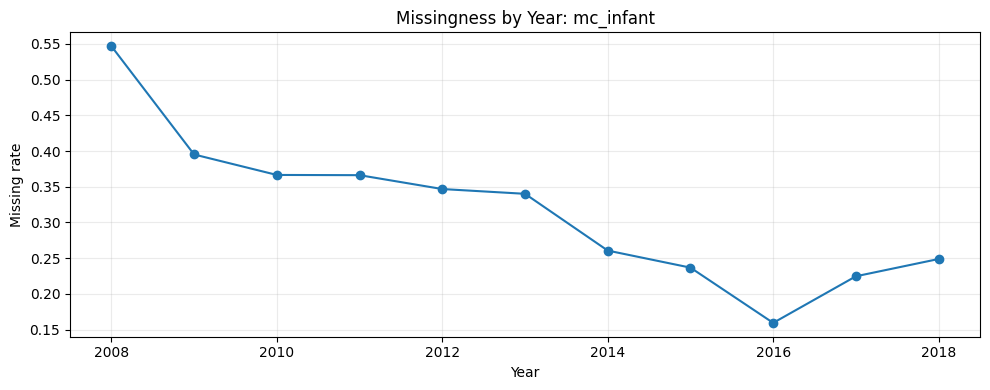

,study_year,mc_infant_missing_rate
0,2008,0.546785
1,2009,0.395164
2,2010,0.366529
3,2011,0.366211
4,2012,0.346802


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

miss_by_year = (
    df.groupby("study_year")["mc_infant"]
      .apply(lambda s: s.isna().mean())
      .reset_index(name="mc_infant_missing_rate")
      .sort_values("study_year")
)

plt.figure(figsize=(10,4))
plt.plot(miss_by_year["study_year"], miss_by_year["mc_infant_missing_rate"], marker="o")
plt.title("Missingness by Year: mc_infant")
plt.xlabel("Year")
plt.ylabel("Missing rate")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

miss_by_year.head()


**3.2 Coverage threshold sensitivity**

This step checks how the results depend on the minimum data coverage rule. If a county only has a few years of non missing data, it can look like a spike or never high just because many years are missing. To avoid this, I require each county to have at least a certain number of years with non missing mc infant values. The code counts how many counties meet the rule when the minimum is 6, 7, or 8 years. Then it plots a bar chart to show how the number of eligible counties changes as the rule becomes stricter.

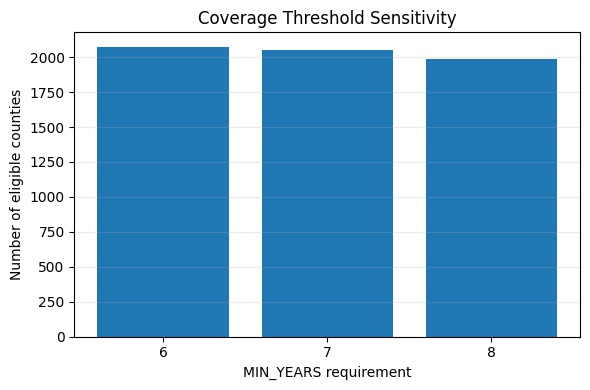

,MIN_YEARS,eligible_counties
0,6,2074
1,7,2049
2,8,1987


In [6]:
def eligible_counties(df, min_years, cost_col="mc_infant"):
    counts = df.dropna(subset=[cost_col]).groupby("county_fips_code")["study_year"].nunique()
    eligible = counts[counts >= min_years].index
    return len(eligible), eligible

rows = []
for min_years in [6, 7, 8]:
    n, _ = eligible_counties(df, min_years)
    rows.append({"MIN_YEARS": min_years, "eligible_counties": n})

coverage_tbl = pd.DataFrame(rows)

plt.figure(figsize=(6,4))
plt.bar(coverage_tbl["MIN_YEARS"].astype(str), coverage_tbl["eligible_counties"])
plt.title("Coverage Threshold Sensitivity")
plt.xlabel("MIN_YEARS requirement")
plt.ylabel("Number of eligible counties")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

coverage_tbl

This table shows how many counties remain under different minimum coverage rules. When I require at least 6 years of non missing mc infant data, 2074 counties are eligible. With a 7 year requirement, 2049 counties remain. With an 8 year requirement, 1987 counties remain. This means some counties have missing childcare cost data in many years. A stricter rule keeps a cleaner and more reliable sample but reduces the sample size. In Milestone 4, I use MIN YEARS equals 8 because it improves reliability for persistence and trajectory analysis, and it only removes a small number of counties compared to MIN YEARS equals 6.

**3.3 Build pooled residuals**（use M2 code）

In M2, I use residual as the parameter to measure the abnormally high cost under the condition of similar income. Therefore, I use residual to construct the trajectory matrix To compare the impact of missing strategy and scaling selection on the stability of clustering.

In [7]:
#Construct the pooled residual as the basis score for anomaly
d_all = df.dropna(subset=["study_year", "county_fips_code", "mc_infant", "mhi_2018"]).copy()

X = np.log1p(d_all[["mhi_2018"]].values)
y = np.log1p(d_all["mc_infant"].values)

lr = LinearRegression().fit(X, y)
d_all["residual_log"] = y - lr.predict(X)

d_all["residual_log"].describe()

,residual_log
count,2.359300e+04
mean,-5.673982e-16
std,2.641627e-01
min,-1.494455e+00
25%,-1.732035e-01
50%,-3.669535e-03
75%,1.599553e-01
max,1.248353e+00


In [8]:
#Residual trajectory matrix
mat = d_all.pivot_table(index="county_fips_code", columns="study_year", values="residual_log", aggfunc="mean")
print("matrix shape:", mat.shape)
print("total missing cells:", int(mat.isna().sum().sum()))
mat.head()

matrix shape: (2904, 11)
total missing cells: 8351


study_year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
county_fips_code,,,,,,,,,,,
01001,-0.406566,-0.427735,-0.445861,-0.426516,-0.409352,-0.392341,-0.358877,-0.307975,-0.295265,-0.280823,-0.274604
01003,-0.357254,-0.350173,-0.368661,-0.365599,-0.348633,-0.333331,-0.324522,-0.292413,-0.269724,-0.241524,-0.236733
01005,-0.385040,-0.364768,-0.341057,-0.300859,-0.205747,-0.185928,-0.203493,-0.158679,-0.189525,-0.176863,-0.188569
01007,-0.483693,-0.419086,-0.393229,-0.314271,-0.199554,-0.150715,-0.142003,-0.150541,-0.159517,-0.206536,-0.212156
01009,-0.193709,-0.180778,-0.162748,-0.119564,-0.088631,-0.043191,-0.020203,0.041278,0.120662,0.188745,0.258928


**3.4  Missing value handling**

This is the second EDA update. In M2, I did not clearly describe how I filled missing values. In M4, I compare two missing value strategies. The first is row mean fill, where I fill missing years using the county own average residual. This is simple and transparent. The second is linear interpolation, where I fill missing years by interpolating across years to better keep the time trend.

In [9]:
# Before comparing the two strategies, I first filter the data using MIN YEARS equals 8.
def filter_min_years(mat, min_years):
    nonmissing = mat.notna().sum(axis=1)
    return mat[nonmissing >= min_years].copy()

def fill_row_mean(mat):
    return mat.apply(lambda r: r.fillna(r.mean()), axis=1)

def fill_linear_interpolate(mat):
    m = mat.reindex(sorted(mat.columns), axis=1)
    m2 = m.T.interpolate(method="linear", limit_direction="both").T
    return m2

MIN_YEARS = 8
mat_ok = filter_min_years(mat, MIN_YEARS)

mat_rowmean = fill_row_mean(mat_ok)
mat_interp = fill_linear_interpolate(mat_ok)

print("eligible counties:", mat_ok.shape[0])
print("row-mean remaining NaN:", int(mat_rowmean.isna().sum().sum()))
print("interp remaining NaN:", int(mat_interp.isna().sum().sum()))

eligible counties: 1987
row-mean remaining NaN: 0
interp remaining NaN: 0


These results show that after applying the MIN YEARS equals 8 coverage rule, 1987 counties remain in the trajectory sample. After filling missing values, both methods produce a complete matrix with no remaining missing entries. Row mean fill removes all NaN values by replacing missing years with each county average residual, and linear interpolation also removes all NaN values by estimating missing years from nearby years. This means the data is ready for clustering without errors from missing values.

In the next step, I compare two missing value strategies for the residual trajectory matrix using a simple clustering diagnostic. I define a helper function that runs KMeans with a fixed number of clusters K and returns the silhouette score. Before clustering, I standardize the input matrix so distance calculations are on a comparable scale. I then compute silhouette scores for two filled matrices, one using row mean fill and the other using linear interpolation across years. I keep K fixed at 4 and use the same scaler for both runs, so the only difference is the missing value method. The resulting table shows whether the clustering quality changes when I switch the imputation strategy, which helps evaluate the stability of the trajectory results.

In [10]:
def kmeans_silhouette(mat_filled, K=4, scaler="standard"):
    X = mat_filled.values
    if scaler == "standard":
        Xs = StandardScaler().fit_transform(X)
    else:
        Xs = RobustScaler().fit_transform(X)
    km = KMeans(n_clusters=K, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    return silhouette_score(Xs, labels)

K_TEST = 4

mat_interp_safe = mat_interp.apply(lambda r: r.fillna(r.mean()), axis=1)

sil_rowmean = kmeans_silhouette(mat_rowmean, K=K_TEST, scaler="standard")
sil_interp  = kmeans_silhouette(mat_interp_safe, K=K_TEST, scaler="standard")

pd.DataFrame({
    "strategy": ["row_mean_fill", "linear_interpolate"],
    "K": [K_TEST, K_TEST],
    "silhouette_standard": [sil_rowmean, sil_interp]
})

,strategy,K,silhouette_standard
0,row_mean_fill,4,0.375957
1,linear_interpolate,4,0.382882


This table compares two missing value strategies for the residual trajectory matrix under the same setting. I keep K equals 4 and use the same standard scaling for both runs, so the only change is how missing years are filled. The silhouette scores are very close, which suggests the clustering quality is not very sensitive to the imputation choice. Linear interpolation is slightly higher than row mean fill, which means it separates clusters a little better in this case, but the difference is small. Based on this, I can use linear interpolation as the default and treat row mean fill as a robustness check that gives a similar result.


**3.5 Scaling choice**


In this step, I test whether my clustering results depend on the scaling method. I keep the same filled trajectory matrix and fix K equals 4, so the only change is how the features are scaled before KMeans. First I use StandardScaler, which centers each feature and scales it to unit variance. Then I use RobustScaler, which is less sensitive to extreme values because it relies more on percentiles. I compare the silhouette scores from the two runs to see if the cluster separation changes under a different scaling choice. This is a simple robustness check for the preprocessing step.

In [11]:
# Fix the K value
K_TEST = 4
sil_std = kmeans_silhouette(mat_rowmean, K=K_TEST, scaler="standard")
sil_rob = kmeans_silhouette(mat_rowmean, K=K_TEST, scaler="robust")

pd.DataFrame({
    "scaler": ["StandardScaler", "RobustScaler"],
    "K": [K_TEST, K_TEST],
    "silhouette": [sil_std, sil_rob]
})

,scaler,K,silhouette
0,StandardScaler,4,0.375957
1,RobustScaler,4,0.375834


This table compares two scaling methods under the same clustering setting. I keep K equals 4 and use the same filled trajectory matrix, so the only change is the scaler. The silhouette scores are almost identical for StandardScaler and RobustScaler, which means the clustering quality does not really change when I switch the scaling method. This suggests the results are not sensitive to this preprocessing choice. Based on this, I use StandardScaler as the default and treat RobustScaler as a simple robustness check that leads to the same conclusion.


# **4 Analysis and Experiments**

In M2, I respectively used two methods for clustering, hierarchical clustering and K-means. In M4, I will conduct a more in-depth and detailed exploration and research on clustering through three experiments

**4.1 Residual modeling robustness**

I first compute pooled residuals by fitting one log cost versus log income regression across all years. The residual measures how much a county cost is above what income alone would predict.


In [12]:
d_base = df.dropna(subset=["county_fips_code", "study_year", "mc_infant", "mhi_2018"]).copy()

X = np.log1p(d_base[["mhi_2018"]].values)
y = np.log1p(d_base["mc_infant"].values)

lr_pool = LinearRegression().fit(X, y)
d_base["resid_pool"] = y - lr_pool.predict(X)

d_base[["resid_pool"]].describe()

,resid_pool
count,2.359300e+04
mean,-5.673982e-16
std,2.641627e-01
min,-1.494455e+00
25%,-1.732035e-01
50%,-3.669535e-03
75%,1.599553e-01
max,1.248353e+00


I also compute year specific residuals by fitting the regression separately for each year. This checks whether the anomaly results depend on using one pooled model.

In [13]:
d_base["resid_year"] = np.nan

for yr, g in d_base.groupby("study_year"):
    Xy = np.log1p(g[["mhi_2018"]].values)
    yy = np.log1p(g["mc_infant"].values)
    m = LinearRegression().fit(Xy, yy)
    d_base.loc[g.index, "resid_year"] = yy - m.predict(Xy)

d_base[["resid_year"]].describe()

,resid_year
count,2.359300e+04
mean,-1.487764e-16
std,2.560688e-01
min,-1.566676e+00
25%,-1.711357e-01
50%,1.076797e-03
75%,1.491741e-01
max,1.187929e+00


This step checks whether my anomaly counties are stable when I change how residuals are computed. I set TOP_PCT to 0.05, so in each year I flag the top 5 percent of residual values as anomalies. I do this twice: first using pooled residuals from one regression across all years, and then using year specific residuals from separate regressions each year. For each method, I collect the counties that ever appear in the yearly top 5 percent and store them as a set. Then I compare the two sets using overlap counts and the Jaccard overlap, which is intersection divided by union. A higher Jaccard value means the anomaly list is more consistent across the two residual models, so the result is more robust.

In [14]:
TOP_PCT = 0.05

def get_anomaly_set(d, resid_col):
    s = []
    for yr, g in d.dropna(subset=[resid_col]).groupby("study_year"):
        thr = g[resid_col].quantile(1 - TOP_PCT)
        s.append(g.loc[g[resid_col] >= thr, "county_fips_code"])
    return set(pd.concat(s).unique())

set_pool = get_anomaly_set(d_base, "resid_pool")
set_year = get_anomaly_set(d_base, "resid_year")

inter = len(set_pool & set_year)
union = len(set_pool | set_year)
jaccard = inter / union if union > 0 else np.nan

print("Anomaly counties pooled:", len(set_pool))
print("Anomaly counties year specific:", len(set_year))
print("Overlap:", inter)
print("Jaccard overlap:", round(jaccard, 3))

Anomaly counties pooled: 241
Anomaly counties year specific: 246
Overlap: 235
Jaccard overlap: 0.933


These results compare anomaly county lists from pooled residuals and year specific residuals. The pooled method flags 241 unique counties as anomalies, and the year specific method flags 246. The overlap is 235 counties, which means most anomaly counties are the same under both approaches. The Jaccard overlap is 0.933, which is very high. This suggests the anomaly identification is robust to how residuals are modeled, and only a small number of borderline counties change when switching between pooled and year specific regressions.

Next, I will further explore the issue to investigate which regions have repeatedly abnormal figures, that is, what proportion of a county is judged as top residual in the available years. By calculating the proportion, we can obtain the preliminary results and determine whether this anomaly is persistent or occurs only occasionally. However, there is a problem here. In the previous step, I used a relatively robust method to determine which counties were judged as abnormal, but the data missing makes persistence prone to misjudgment, so counties with fewer years of data are likely to be misjudged as spike or never. A new robust test is needed, but the code has not been solved yet.

My idea is to summarize the thresholds separately by year and form persistance. Here are my initial results.

In [15]:
def persistence_table(d, resid_col, top_pct=0.05):
    d2 = d.dropna(subset=[resid_col]).copy()
    d2["is_top"] = 0
    for yr, g in d2.groupby("study_year"):
        thr = g[resid_col].quantile(1 - top_pct)
        d2.loc[g.index, "is_top"] = (g[resid_col] >= thr).astype(int)

    pers = (
        d2.groupby("county_fips_code")
          .agg(years_avail=("study_year","nunique"),
               years_top=("is_top","sum"),
               persistence=("is_top","mean"))
          .reset_index()
    )
    return pers

pers_pool = persistence_table(d_base, "resid_pool", top_pct=TOP_PCT)
pers_year = persistence_table(d_base, "resid_year", top_pct=TOP_PCT)


**4.2 Threshold sensitivity**

All the above situations were carried out under the condition that the cutoff was 5%. This experiment will determine that the anomaly cutoff is not only top 5 percent, with the aim of comparing different comparison top values.

First，I tests threshold sensitivity for the persistence results. I compute a persistence score for each county by marking the top residual counties within each year, then summarizing how often each county appears in the top group. I keep the same rules for minimum coverage and the persistent cutoff, but I change the anomaly threshold from top 2.5 percent to top 5 percent and top 10 percent. For each threshold, I print the share of counties that are classified as persistent. This shows whether the persistence conclusion is stable when the anomaly cutoff is changed.

In [16]:
def persistent_share(d, resid_col, top_pct, min_years=8, persist_cut=0.30):
    pers = persistence_table(d, resid_col, top_pct=top_pct)
    pers_ok = pers[pers["years_avail"]>=min_years].copy()
    share_persistent = (pers_ok["persistence"]>=persist_cut).mean()
    return share_persistent, pers_ok

for pct in [0.025, 0.05, 0.10]:
    share, _ = persistent_share(d_base, "resid_year", top_pct=pct, min_years=8, persist_cut=0.30)
    print("top pct", pct, "persistent share", round(share, 3))

top pct 0.025 persistent share 0.034
top pct 0.05 persistent share 0.064
top pct 0.1 persistent share 0.111


These results show that the share of counties labeled as persistent increases when the anomaly cutoff becomes less strict. With a top 2.5 percent cutoff, about 3.4 percent of counties are persistent. With top 5 percent, about 6.4 percent are persistent. With top 10 percent, about 11.1 percent are persistent. This pattern is expected because a larger top percent flags more counties as anomalies each year, so it is easier for a county to appear in the top group in many years and pass the persistence cutoff. Overall, this shows persistence results are sensitive to the anomaly threshold, so I treat top 5 percent as the main setting and use the other cutoffs as robustness checks.

Next, I will verify whether the obtained results will be affected by changes in geographical location, or whether this step is to rule out errors caused by non-data reasons.check whether the geographic pattern of persistent counties is stable when I change the anomaly cutoff. I first compute persistence scores using year specific residuals and keep only counties with at least 8 available years. Then I label a county as persistent if its persistence is at least 0.30. After that, I merge in the state information and count how many persistent counties appear in each state. I repeat the same process under two cutoffs, top 5 percent and top 10 percent, and list the top 10 states for each setting. If the same states stay near the top across both cutoffs, it suggests the state concentration result is robust. If the top states change a lot, it suggests the geographic conclusion depends on the threshold choice and should be interpreted more carefully.

In [20]:
# pick the state column
if "state_abbreviation" in df.columns:
    state_col = "state_abbreviation"
else:
    state_col = None

if state_col is None:
    print("No state column found")
else:
    county_state = df[["county_fips_code", state_col]].drop_duplicates()

    rows = []
    for pct in [0.05, 0.10]:
        _, pers_ok = persistent_share(d_base, "resid_year", top_pct=pct, min_years=8, persist_cut=0.30)

        pers_ok = pers_ok.merge(county_state, on="county_fips_code", how="left")

        pers_ok = pers_ok[pers_ok["persistence"] >= 0.30]

        top_states = pers_ok[state_col].value_counts().head(10)

        tmp = pd.DataFrame({
            "top_pct": pct,
            "state": top_states.index,
            "count": top_states.values
        })
        rows.append(tmp)

    top_states_tbl = pd.concat(rows, ignore_index=True)
    top_states_tbl
    print(top_states_tbl)
    top_states_tbl.head(20)

    top_pct state  count
0      0.05    CA     47
1      0.05    WA     39
2      0.05    OH      9
3      0.05    MA      8
4      0.05    VA      8
5      0.05    IL      4
6      0.05    MN      4
7      0.05    WI      3
8      0.05    OR      2
9      0.05    KY      1
10     0.10    CA     58
11     0.10    WA     39
12     0.10    OH     26
13     0.10    IL     17
14     0.10    VA     15
15     0.10    WI     13
16     0.10    MA     12
17     0.10    MN     10
18     0.10    PA      4
19     0.10    OR      4


Under both cutoffs, CA and WA consistently have the largest number of persistent counties, suggesting a robust geographic concentration. When the cutoff expands from top 5 percent to top 10 percent, more states move into the top list and counts increase, which shows the state ranking is partly sensitive to the anomaly threshold.

**4.3 Trajectory clustering stability**

In M2, I use two methods for clustering. At this step, I will conduct a more in-depth exploration of the value of K in Kmeans, which is listed as an unsolved problem in M2. At the same time, hierarchical clustering is used for comparison.

In [21]:
# KMeans compare K 3 vs 4 with silhouette and cluster sizes
from sklearn.preprocessing import StandardScaler

def run_kmeans(mat_filled, K):
    Xs = StandardScaler().fit_transform(mat_filled.values)
    km = KMeans(n_clusters=K, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    sil = silhouette_score(Xs, labels)
    sizes = pd.Series(labels).value_counts().sort_index()
    return labels, sil, sizes

for K in [3, 4]:
    labels, sil, sizes = run_kmeans(mat_rowmean, K)
    print("K", K, "silhouette", round(sil, 3))
    print("cluster sizes", sizes.to_dict())

K 3 silhouette 0.454
cluster sizes {0: 1096, 1: 283, 2: 608}
K 4 silhouette 0.376
cluster sizes {0: 653, 1: 429, 2: 185, 3: 720}


The chart has already been made in M2. Now I will narrow down the scope and make the chart again.

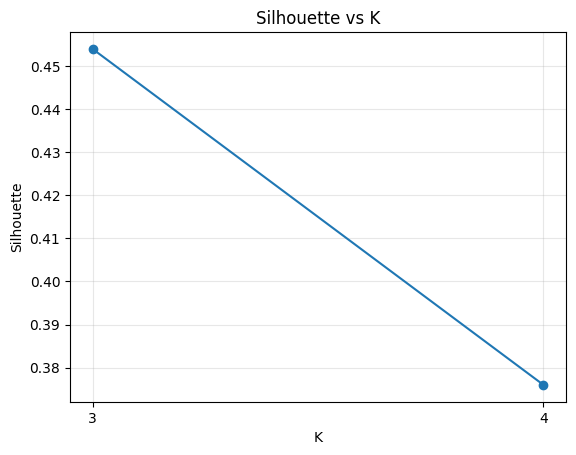

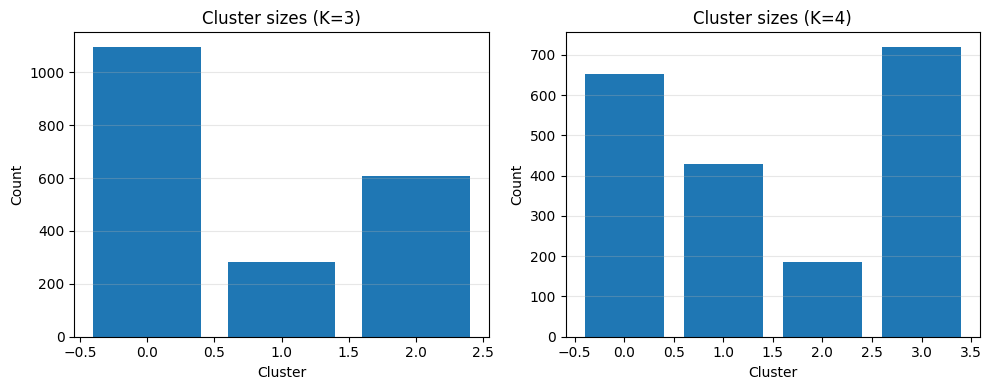

In [25]:
import matplotlib.pyplot as plt

Ks = [3, 4]

# 1) run kmeans and save results
sils = []
sizes = {}
for K in Ks:
    _, sil, sz = run_kmeans(mat_rowmean, K)
    sils.append(sil)
    sizes[K] = sz

# 2) plot silhouette vs K
plt.figure()
plt.plot(Ks, sils, marker="o")
plt.xticks(Ks)
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("Silhouette vs K")
plt.grid(True, alpha=0.3)
plt.show()
# 3) plot cluster sizes for each K
fig, axes = plt.subplots(1, len(Ks), figsize=(5*len(Ks), 4))
axes = [axes] if len(Ks) == 1 else axes

for ax, K in zip(axes, Ks):
    sz = sizes[K].sort_index()
    ax.bar(sz.index, sz.values)
    ax.set_title(f"Cluster sizes (K={K})")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

I choose K equals 3 because it has a higher silhouette score than K equals 4, and the clusters stay reasonably sized and easier to interpret.

Next, after completing the clustering, I will return to verify again whether the previously conducted verification of filling in the missing values will change the shape of the cluster.

This code plots the average residual trajectory for each cluster when K equals 3. First, it assigns each county to a cluster using KMeans on the filled trajectory matrix. Then it computes the mean residual value for each year within each cluster, which gives a typical time pattern for that cluster. I run the same steps for two missing value strategies, row mean fill and linear interpolation, and plot the mean trajectories for both. This lets me check whether the main trajectory shapes are similar across imputation choices, which is a simple robustness check for the trajectory clustering results.

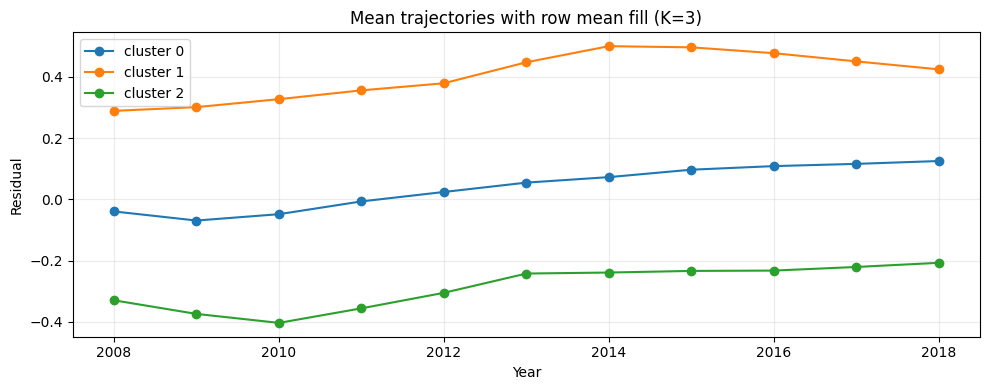

Silhouette: 0.454


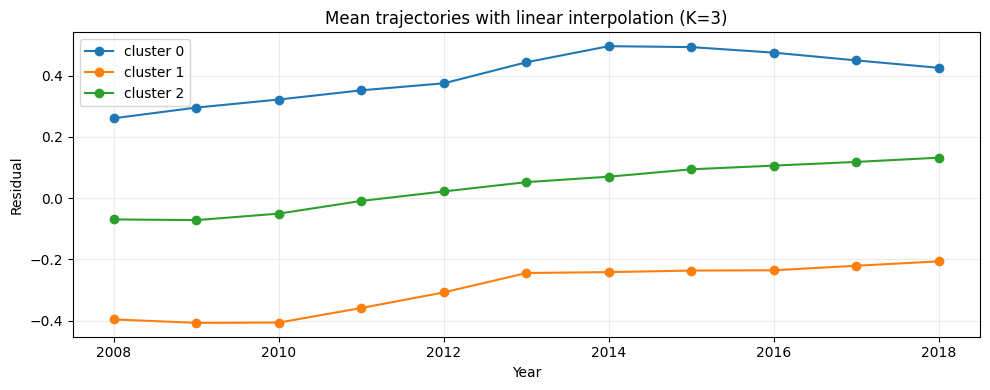

Silhouette: 0.458


In [26]:
def mean_traj(mat, labels):
    tmp = mat.copy()
    tmp["cluster"] = labels
    return tmp.groupby("cluster").mean()
# run KMeans once and plot helper
def plot_mean_traj(mat, K, title):
    labels, sil, _ = run_kmeans(mat, K)
    means = mean_traj(mat, labels)
    years = sorted(mat.columns)

    plt.figure(figsize=(10,4))
    for c in means.index:
        plt.plot(years, means.loc[c, years], marker="o", label="cluster " + str(c))
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Residual")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Silhouette:", round(sil, 3))
# compare two fill strategies with K=3
plot_mean_traj(mat_rowmean, 3, "Mean trajectories with row mean fill (K=3)")
plot_mean_traj(mat_interp, 3, "Mean trajectories with linear interpolation (K=3)")

Both imputation methods produce three clear trajectory types, with one consistently high residual group, one middle group that rises over time, and one consistently low group. The cluster labels change across methods, but the overall shapes and ordering remain similar, which suggests the trajectory patterns are reasonably robust to the missing value strategy.

# **5 Findings & Interpretations**

First, the most stable result is that the anomaly county list is highly consistent across residual modeling choices. When I compare pooled residuals versus year specific residuals using the same top 5 percent rule, the anomaly sets overlap strongly and the Jaccard overlap is 0.933. This means most counties flagged as unusually high cost relative to income similar peers remain the same even when I change how residuals are computed. This supports the idea that the main anomaly signal is not driven by one modeling choice. It also suggests that the counties repeatedly flagged as anomalies are good candidates for deeper structural explanations, such as long run supply limits or local market constraints that push costs above what income alone would predict.

Second, some parts of the results are less stable and depend on design choices. The persistence classification is sensitive to the anomaly cutoff. When I change the yearly cutoff from top 2.5 percent to top 5 percent and top 10 percent, the share of counties labeled as persistent rises from 0.034 to 0.064 and then to 0.111. This is expected because a larger cutoff flags more counties each year, so it becomes easier for a county to meet the persistence threshold. Geographic rankings also shift under different cutoffs. For example, CA and WA stay at the top under both top 5 percent and top 10 percent, but other states move up when the cutoff becomes less strict, such as OH and IL. This shows that a small group of states is robust, while the rest of the ranking is more sensitive. For trajectory clustering, the main three shape patterns remain similar under row mean fill and linear interpolation, but the cluster labels can switch, which is normal because cluster numbers do not have fixed meaning.

Third, these patterns matter for real decisions because they separate long run structural risk from short run noise. Counties that remain anomalous across residual models and appear persistently high over time are stronger candidates for long term policy attention. These counties may need supply side investigation, capacity expansion, or sustained support rather than one time fixes. In contrast, counties that only look persistent under a loose cutoff or that appear as spikes in only a few years are better treated as monitoring targets. For those cases, the first step should be short term validation, checking local conditions and data coverage before making long horizon policy conclusions.

Confidence statement. I am more confident about the existence of a core anomaly set because it holds under both pooled and year specific residual models, but I am less confident about the exact size and ranking of the persistent group because it changes under different anomaly cutoffs and preprocessing choices.